In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Coleta de dados

In [2]:
df = pd.read_csv("creditcard.csv", encoding="utf-8")
display (df)

df.columns

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

## 2. Inspeção 

In [3]:
display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

None

In [4]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [5]:
total_duplicadas = df.duplicated().sum()
percentual_duplicadas = (total_duplicadas / len(df)) * 100
print(f"Total de duplicadas: {total_duplicadas}")
print(f"Percentual {percentual_duplicadas:.2f}%")

Total de duplicadas: 1081
Percentual 0.38%


Foram identificadas 1081 linhas duplicadas

In [6]:
duplicadas_completas = df[df.duplicated(keep=False)]
display(duplicadas_completas.sort_values(by=list(df.columns)).head(10))

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
34,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
32,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
112,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
113,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
114,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
115,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
220,145.0,-2.420413,1.947885,0.553646,0.983069,-0.281518,2.408958,-1.401613,-0.188299,0.675878,...,1.213826,-1.238620,0.006927,-1.724222,0.239603,-0.313703,-0.188281,0.119831,6.00,0
221,145.0,-2.420413,1.947885,0.553646,0.983069,-0.281518,2.408958,-1.401613,-0.188299,0.675878,...,1.213826,-1.238620,0.006927,-1.724222,0.239603,-0.313703,-0.188281,0.119831,6.00,0


In [7]:
df["Class"].value_counts()

total_fraudes = df["Class"].sum()
percentual_fraudes = (total_fraudes / len(df)) * 100
print(f"Total de fraudes: {total_fraudes}")
print(f"Percentual de fraude: {percentual_fraudes}")

Total de fraudes: 492
Percentual de fraude: 0.1727485630620034


In [8]:
total_nfraudes = df[df["Class"] == 0]
total_nfraudes = len(total_nfraudes)
percentual_nfraudes = (total_nfraudes / len(df)) * 100
print(f"Total de casos não fraudulentos: {total_nfraudes}")
print(f"Percentual de casos fraudelento: {percentual_nfraudes}")

Total de casos não fraudulentos: 284315
Percentual de casos fraudelento: 99.82725143693798


Foi observado que 0,172% das transações são fraude, contra 99,827% não-fraude. Isso confirma que o dataset é extremamente desbalanceado; situação típica em problemas de detecção de fraude, já que casos fraudulentos são naturalmente raros. Esse desbalanceamento precisa ser considerado ao interpretar médias e proporções em análises futuras.

## 3. Tratamento de dados

In [9]:
duplicated = df[df.duplicated()]
duplicated["Class"].value_counts(normalize=True)

Class
0    0.982424
1    0.017576
Name: proportion, dtype: float64

In [10]:
total_antes = len(df)
df = df.drop_duplicates()
total_depois = len(df)

print(f"Total antes da remoção: {total_antes}")
print(f"Total depois da remoção: {total_depois}")

total_removido = total_antes - total_depois
print(f"Total de linhas removidas: {total_removido}")

Total antes da remoção: 284807
Total depois da remoção: 283726
Total de linhas removidas: 1081


A investigação identificou 1.081 linhas duplicadas, correspondentes a aproximadamente 0,38% do total de registros. Dado que as colunas V1 a V28 resultam de uma transformação PCA produzindo valores contínuos com múltiplas casas decimais, a coincidência exata entre 30 variáveis distintas em registros genuinamente diferentes é estatisticamente improvável, o que caracteriza essas ocorrências como artefatos técnicos de coleta, e não um padrão real de fraude repetida. Reforçando essa hipótese, a taxa de fraude dentro do subconjunto duplicado (1,76%) mostrou-se aproximadamente 10 vezes superior à taxa geral do dataset (0,172%), sugerindo concentração de ruído em torno de casos raros, sem indicar comportamento fraudulento genuíno. Diante disso, optou-se pela remoção dos registros duplicados, preservando a primeira ocorrência de cada um. O dataset passou de 284.807 para 283.726 linhas, mantendo íntegros todos os casos únicos de fraude originalmente presentes.

In [11]:
df["Class"].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

## 4. Análise Exploratória / Visualização 

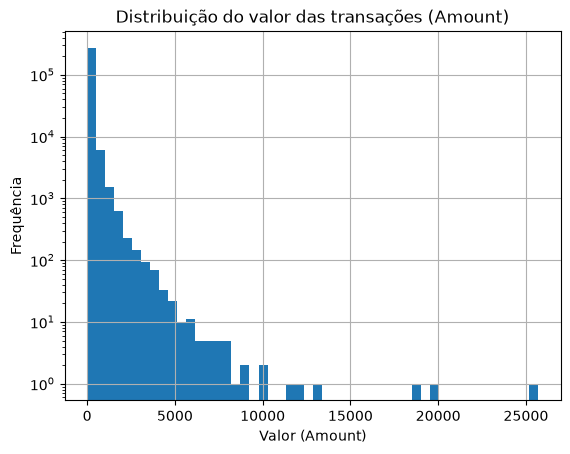

In [12]:
df["Amount"].hist(bins=50)
plt.yscale("log")
plt.title("Distribuição do valor das transações (Amount)")
plt.xlabel("Valor (Amount)")
plt.ylabel("Frequência")
plt.show()

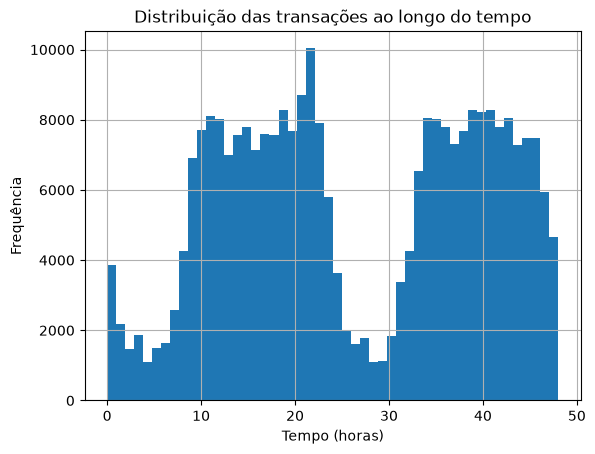

In [13]:
df["Time_horas"] = df["Time"] / 3600

df["Time_horas"].hist(bins=50)
plt.title("Distribuição das transações ao longo do tempo")
plt.xlabel("Tempo (horas)")
plt.ylabel("Frequência")
plt.show()

O histograma de Amount revela uma concentração expressiva de transações de baixo valor, enquanto valores mais altos são consideravelmente mais raros uma distribuição assimétrica à direita, coerente com a diferença observada entre média e valor máximo na etapa de inspeção. Já o histograma de Time evidencia um padrão cíclico ao longo do período analisado, com dois ciclos de alta e baixa atividade, compatíveis com os dois dias cobertos pelo dataset.

In [14]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,88.413575,250.379023,0.0,5.67,22.00,77.46,25691.16
1,473.0,123.871860,260.211041,0.0,1.00,9.82,105.89,2125.87


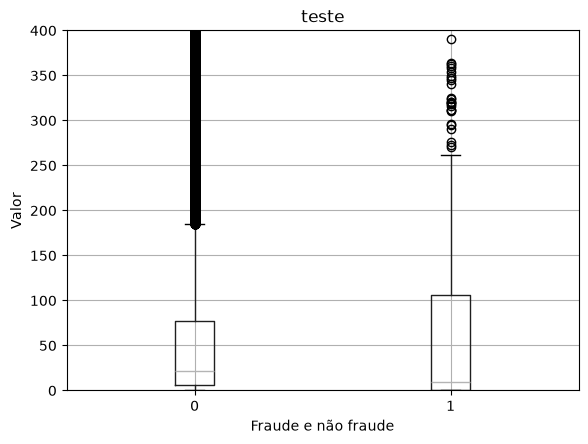

In [15]:
df.boxplot(column="Amount", by="Class")
plt.title("teste")
plt.suptitle("")
plt.xlabel("Fraude e não fraude")
plt.ylabel("Valor")
plt.ylim(0, 400)
plt.show()

A comparação por boxplot entre transações fraudulentas e não fraudulentas revela que a caixa (intervalo interquartil) do grupo de fraude é maior e sua base possui valores mais altos que a do grupo não-fraude, apesar do valor máximo absoluto de fraude ser bem menor (conforme observado no describe agrupado). Esse padrão sugere um comportamento bimodal dentro das transações fraudulentas: uma parcela de valores muito baixos, possivelmente associada a testes de validade de cartão ("card testing"), e uma parcela de valores mais altos, quando a fraude é de fato explorada. Isso reforça que o valor da transação isoladamente não é um indicador direto de fraude, mas um dos fatores que, combinado a outras variáveis, pode ajudar a identificar padrões suspeitos.

In [16]:
correlacao = df.corr(numeric_only=True)
correlacao["Class"].sort_values(ascending=False)

Class         1.000000
V11           0.149067
V4            0.129326
V2            0.084624
V19           0.033631
V8            0.033068
V21           0.026357
V27           0.021892
V20           0.021486
V28           0.009682
Amount        0.005777
V22           0.004887
V26           0.004265
V25           0.003202
V15          -0.003300
V13          -0.003897
V23          -0.006333
V24          -0.007210
Time         -0.012359
Time_horas   -0.012359
V6           -0.043915
V5           -0.087812
V9           -0.094021
V1           -0.094486
V18          -0.105340
V7           -0.172347
V3           -0.182322
V16          -0.187186
V10          -0.206971
V12          -0.250711
V14          -0.293375
V17          -0.313498
Name: Class, dtype: float64

A matriz de correlação com a variável Class revela que as variáveis com maior correlação negativa são V17, V14, V12 e V10; ou seja, valores mais baixos nessas variáveis estão associados a uma maior probabilidade de fraude. Já as variáveis V4, V11, V2 e V19 apresentam as maiores correlações positivas, indicando que valores mais altos nessas variáveis tendem a se associar a transações fraudulentas. Embora essas variáveis sejam anonimizadas por PCA (sem significado direto no mundo real), esse resultado demonstra que existem padrões estatísticos claramente capturáveis nos dados, mesmo sem conhecimento do significado original de cada uma, uma característica relevante caso o projeto seja futuramente estendido para um modelo preditivo de classificação.

## 5. Conclusão

Esta análise exploratória do dataset Credit Card Fraud Detection permitiu identificar padrões relevantes sobre o comportamento das transações fraudulentas. O primeiro achado foi o desbalanceamento extremo entre as classes, com apenas 0,172% das transações classificadas como fraude. No tratamento de dados, foram identificadas 1.081 linhas duplicadas, que representavam um artefato técnico de coleta e não um padrão real de fraude repetida. Após a remoção, o dataset passou de 284.807 para 283.726 registros, sem perda de nenhum caso único de fraude.

Na análise das distribuições, o valor das transações (Amount) mostrou-se fortemente concentrado em valores baixos, com poucos casos de valor elevado puxando a distribuição para a direita. O volume de transações ao longo do tempo (Time) seguiu um padrão cíclico, compatível com os dois dias cobertos pelo dataset. Ao comparar transações fraudulentas e não fraudulentas, notou-se que a fraude apresenta maior variabilidade de valores dentro da faixa comum de transações, o que sugere a existência de mais de um comportamento distinto entre os casos fraudulentos.

A matriz de correlação apontou as variáveis V17, V14, V12, V10, V4, V11, V2 e V19 como as mais relacionadas à variável alvo. Isso mostra que, mesmo com os dados anonimizados por PCA, existem padrões estatísticos consistentes que poderiam ser aproveitados em uma futura aplicação preditiva.